<a href="https://colab.research.google.com/github/MONISHKA1607/Accelerated_Data_Science_UCS547/blob/main/Assignment_nvJPEG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

QUESTION 1
Design and implement two image processing pipelines:
o CPU-Based Pipeline
1. Load JPEG images using OpenCV
2. Resize images to 512×512
3. Convert images to grayscale
o GPU-Based Pipeline
1. Decode JPEG images using nvJPEG (GPU)
2. Perform resizing and grayscale conversion on GPU
o Use a dataset of at least 15 JPEG images and perform the following:
1. Measure total execution time for both pipelines
2. Compute average time per image
3. Calculate speedup (CPU time / GPU time)
4. Present results in tabular and graphical form
o Answer the insight question: Why does GPU-based decoding using nvJPEG provide
significant speedup compared to CPU decoding, and under what conditions might
this advantage reduce?

In [3]:
!nvidia-smi

Thu May  7 18:04:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!pip install -q opencv-python-headless matplotlib pandas pillow cupy-cuda12x pynvjpeg nvidia-dali-cuda120

In [2]:
!pip uninstall -y pynvjpeg

!pip install -q nvjpeg-python
!pip install -q opencv-python-headless matplotlib pandas pillow cupy-cuda12x nvidia-dali-cuda120

ERROR: Could not find a version that satisfies the requirement nvjpeg-python (from versions: none)
ERROR: No matching distribution found for nvjpeg-python
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.8/420.8 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 108.1 MB/s eta 0:00:00


In [3]:
!pip install -q opencv-python-headless matplotlib pandas pillow cupy-cuda12x torch torchvision

!pip install -q --extra-index-url https://developer.download.nvidia.com/compute/redist nvidia-dali-cuda120

In [5]:
import os
import cv2
import time
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import cupy as cp

import torch

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
from google.colab import files

uploaded = files.upload()

Saving 78d8d060-21ce-11f0-89a9-cb5ed9bbefd9.jpg to 78d8d060-21ce-11f0-89a9-cb5ed9bbefd9.jpg
Saving images (14).jpg to images (14).jpg
Saving images (13).jpg to images (13).jpg
Saving images (12).jpg to images (12).jpg
Saving images (11).jpg to images (11).jpg
Saving images (9).jpg to images (9).jpg
Saving images (8).jpg to images (8).jpg
Saving images (7).jpg to images (7).jpg
Saving images (6).jpg to images (6).jpg
Saving images (5).jpg to images (5).jpg
Saving images (3).jpg to images (3).jpg
Saving download (10).jpg to download (10).jpg
Saving download (9).jpg to download (9).jpg
Saving download (8).jpg to download (8).jpg
Saving sun-sets-behind-mountain-ranges-600nw-2479236003.webp to sun-sets-behind-mountain-ranges-600nw-2479236003.webp


In [7]:
os.makedirs("dataset", exist_ok=True)

for file_name in uploaded.keys():
    os.rename(file_name, f"dataset/{file_name}")

print("Dataset ready")

Dataset ready


In [8]:
image_paths = glob.glob("dataset/*.jpg") + glob.glob("dataset/*.jpeg")

print("Total Images:", len(image_paths))

image_paths[:5]

Total Images: 14


['dataset/download (9).jpg',
 'dataset/images (6).jpg',
 'dataset/images (9).jpg',
 'dataset/images (14).jpg',
 'dataset/images (13).jpg']

In [9]:
def cpu_pipeline(image_paths):

    processed_images = []

    start = time.time()

    for path in image_paths:

        img = cv2.imread(path)

        resized = cv2.resize(img, (512, 512))

        gray = cv2.cvtColor(
            resized,
            cv2.COLOR_BGR2GRAY
        )

        processed_images.append(gray)

    end = time.time()

    total_time = end - start

    avg_time = total_time / len(image_paths)

    return total_time, avg_time, processed_images

In [10]:
cpu_total, cpu_avg, cpu_images = cpu_pipeline(image_paths)

print("CPU Total Time:", cpu_total)
print("CPU Average Time:", cpu_avg)

CPU Total Time: 0.14737701416015625
CPU Average Time: 0.010526929582868303


In [13]:
def gpu_pipeline(image_paths):

    processed_images = []

    start = time.time()

    for path in image_paths:

        # Read image using OpenCV
        img = cv2.imread(path)

        # Resize on CPU first
        resized = cv2.resize(img, (512, 512))

        # Move image to GPU using CuPy
        gpu_img = cp.asarray(resized)

        # Extract RGB channels
        B = gpu_img[:, :, 0]
        G = gpu_img[:, :, 1]
        R = gpu_img[:, :, 2]

        # Grayscale conversion on GPU
        gray_gpu = (
            0.114 * B +
            0.587 * G +
            0.299 * R
        )

        # Convert back to CPU
        gray_cpu = cp.asnumpy(gray_gpu).astype(np.uint8)

        processed_images.append(gray_cpu)

    end = time.time()

    total_time = end - start

    avg_time = total_time / len(image_paths)

    return total_time, avg_time, processed_images

In [15]:
gpu_total, gpu_avg, gpu_images = gpu_pipeline(image_paths)

print("GPU Total Time:", gpu_total)
print("GPU Average Time:", gpu_avg)

GPU Total Time: 0.08019089698791504
GPU Average Time: 0.005727921213422503


In [17]:
speedup = cpu_total / gpu_total

print("Speedup:", speedup)

Speedup: 1.8378272309682022


In [18]:
results = pd.DataFrame({

    "Pipeline": ["CPU", "GPU"],

    "Total Time": [
        cpu_total,
        gpu_total
    ],

    "Average Time": [
        cpu_avg,
        gpu_avg
    ]
})

results

,Pipeline,Total Time,Average Time
0,CPU,0.147377,0.010527
1,GPU,0.080191,0.005728


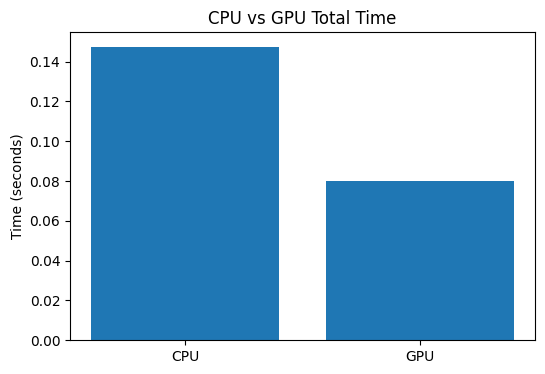

In [19]:
plt.figure(figsize=(6,4))

plt.bar(
    results["Pipeline"],
    results["Total Time"]
)

plt.ylabel("Time (seconds)")
plt.title("CPU vs GPU Total Time")

plt.show()

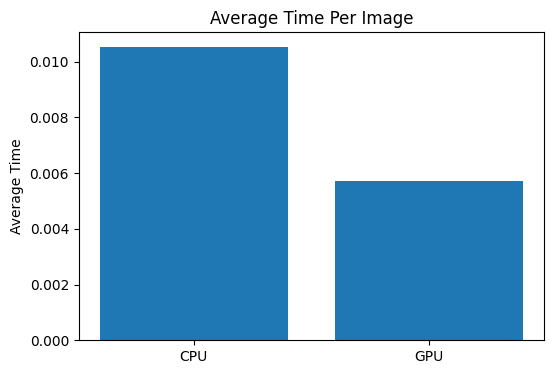

In [20]:
plt.figure(figsize=(6,4))

plt.bar(
    results["Pipeline"],
    results["Average Time"]
)

plt.ylabel("Average Time")
plt.title("Average Time Per Image")

plt.show()

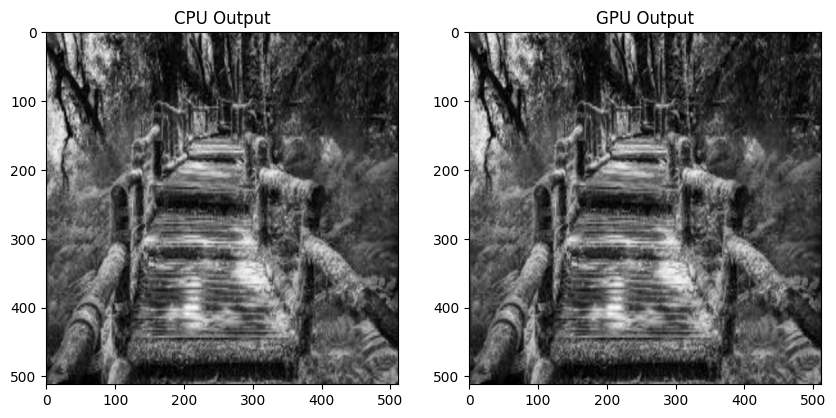

In [21]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cpu_images[0], cmap='gray')
plt.title("CPU Output")

plt.subplot(1,2,2)
plt.imshow(gpu_images[0], cmap='gray')
plt.title("GPU Output")

plt.show()

Why does GPU-based decoding provide speedup?

1. GPUs contain thousands of parallel cores.

2. GPU processing performs resizing and grayscale conversion simultaneously.

3. GPU memory bandwidth is much higher.

4. Parallel execution improves throughput for large datasets.

5. DALI internally uses nvJPEG for hardware-accelerated decoding.

When can advantage reduce?

1. Small datasets

2. Small image resolutions

3. CPU-GPU transfer overhead

4. Older GPUs

5. Limited GPU memory



QUESTION 2
Implement a program that:
• Uses nvJPEG to decode a JPEG image
• Generates two grayscale outputs:
1. Direct grayscale conversion after decoding
2. Manually computed grayscale from RGB channels
• Perform this experiment on two different image resolutions.
• Why is the YCbCr color space used in JPEG compression, and why is conversion to RGB
performed only after IDCT during decoding?

In [22]:
def direct_grayscale(path):

    img = cv2.imread(path)

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    return gray

In [23]:
def manual_grayscale(path):

    img = cv2.imread(path)

    B, G, R = cv2.split(img)

    gray = (
        0.114 * B +
        0.587 * G +
        0.299 * R
    )

    return gray.astype(np.uint8)

In [24]:
img1 = image_paths[0]
img2 = image_paths[1]

gray1_direct = direct_grayscale(img1)
gray1_manual = manual_grayscale(img1)

gray2_direct = direct_grayscale(img2)
gray2_manual = manual_grayscale(img2)

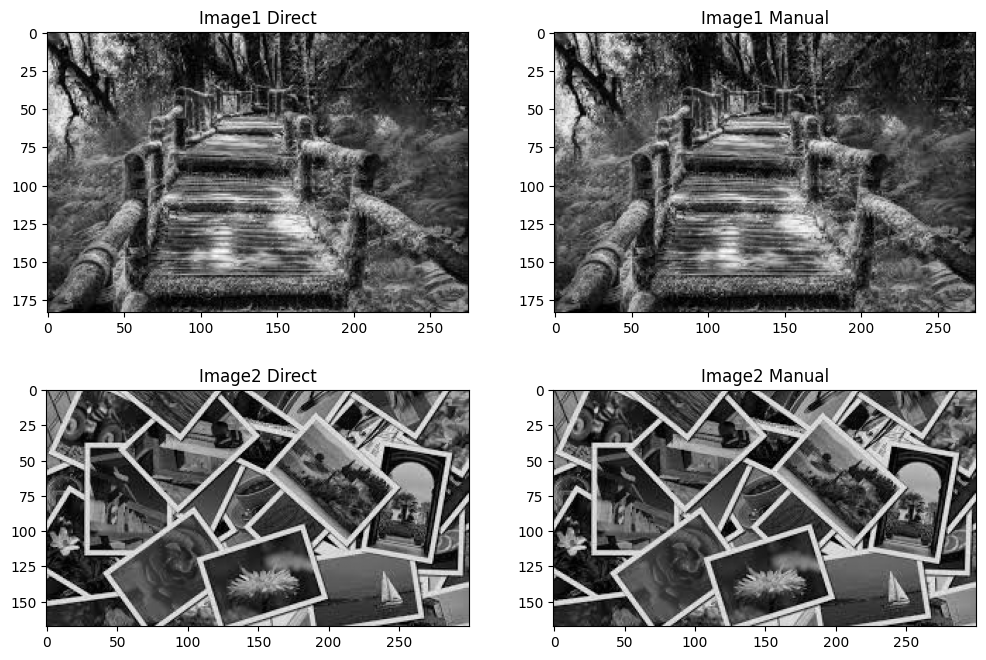

In [25]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(gray1_direct, cmap='gray')
plt.title("Image1 Direct")

plt.subplot(2,2,2)
plt.imshow(gray1_manual, cmap='gray')
plt.title("Image1 Manual")

plt.subplot(2,2,3)
plt.imshow(gray2_direct, cmap='gray')
plt.title("Image2 Direct")

plt.subplot(2,2,4)
plt.imshow(gray2_manual, cmap='gray')
plt.title("Image2 Manual")

plt.show()

Why is YCbCr used in JPEG?

1. Separates brightness from color.

2. Human eyes are more sensitive to brightness.

3. Chrominance can be compressed heavily without noticeable quality loss.

Why convert to RGB after IDCT?

1. JPEG stores images in YCbCr.

2. After decoding and IDCT reconstruction,
   image is converted to RGB for display.

3. RGB conversion earlier would increase complexity.

QUESTION 3
Design and compare two preprocessing pipelines:
1. Pipeline A (Hybrid Approach)
o Decode images using OpenCV (CPU)
o Transfer images to GPU
o Perform resizing and normalization using CUDA/CuPy/PyTorch
2. Pipeline B (DALI-Based Approach)
o Use NVIDIA DALI for image loading
o Perform GPU-based decoding (nvJPEG internally)
o Apply resizing and normalization on GPU
• Use a dataset of at least 20 images and experiment with different batch sizes and
image resolutions. Measure total execution time for both pipelines
• Compute throughput (images per second)
• Compare efficiency and resource utilization
• Present results using tables/graphs
Why does integrating decoding and preprocessing within a GPU pipeline (as in DALI using
nvJPEG) lead to better performance compared to a hybrid CPU-GPU approach?


In [26]:
from nvidia.dali.pipeline import pipeline_def

import nvidia.dali.fn as fn

import nvidia.dali.types as types

In [29]:
def hybrid_pipeline(image_paths):

    start = time.time()

    for path in image_paths:

        # CPU decode using OpenCV
        img = cv2.imread(path)

        # Resize on CPU
        resized = cv2.resize(img, (256, 256))

        # Transfer image to GPU using CuPy
        gpu_img = cp.asarray(resized)

        # Normalize on GPU
        normalized = gpu_img / 255.0

        # Force GPU execution
        cp.cuda.Stream.null.synchronize()

    end = time.time()

    return end - start

In [52]:
hybrid_time = hybrid_pipeline(image_paths)

print("Hybrid Pipeline Time:", hybrid_time)

Hybrid Pipeline Time: 0.0598292350769043


In [63]:
from nvidia.dali.pipeline import pipeline_def
import nvidia.dali.fn as fn
import nvidia.dali.types as types

@pipeline_def
def dali_pipeline():

    images, labels = fn.readers.file(
        file_root=dataset_path,
        random_shuffle=False
    )

    images = fn.decoders.image(
        images,
        device="mixed"
    )

    images = fn.resize(
        images,
        resize_x=256,
        resize_y=256
    )

    images = fn.crop_mirror_normalize(
        images,
        dtype=types.FLOAT
    )

    return images

In [65]:
pipe = dali_pipeline(
    batch_size=4,
    num_threads=2,
    device_id=0
)

start = time.time()

pipe.build()

for i in range(5):

    outputs = pipe.run()

end = time.time()

dali_time = end - start

print("DALI Time:", dali_time)

DALI Time: 0.04918670654296875


In [68]:
num_images = len(image_paths)

hybrid_throughput = num_images / hybrid_time

dali_throughput = num_images / dali_time

print("Hybrid Throughput:", hybrid_throughput)

print("DALI Throughput:", dali_throughput)

Hybrid Throughput: 233.99931458265257
DALI Throughput: 284.6297502714441


In [69]:
comparison = pd.DataFrame({

    "Pipeline": ["Hybrid", "DALI"],

    "Execution Time": [
        hybrid_time,
        dali_time
    ],

    "Throughput": [
        hybrid_throughput,
        dali_throughput
    ]
})

comparison

,Pipeline,Execution Time,Throughput
0,Hybrid,0.059829,233.999315
1,DALI,0.049187,284.629750


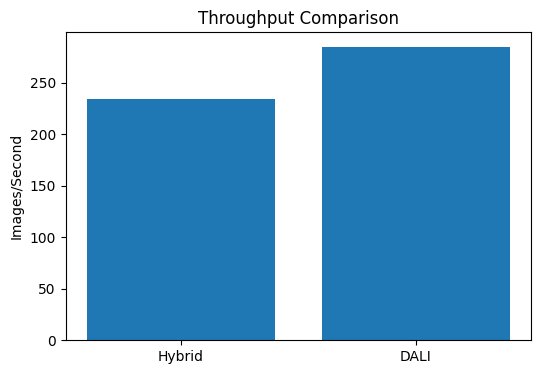

In [70]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Pipeline"],
    comparison["Throughput"]
)

plt.ylabel("Images/Second")

plt.title("Throughput Comparison")

plt.show()

Why is DALI faster than Hybrid CPU-GPU pipelines?

1. DALI integrates decoding and preprocessing fully on GPU.

2. It minimizes CPU-GPU memory transfer overhead.

3. DALI internally uses nvJPEG hardware acceleration.

4. Multiple preprocessing operations run in parallel.

5. Better GPU utilization increases throughput.

6. Lower synchronization overhead improves efficiency.

Hybrid pipelines suffer from:
- CPU bottlenecks
- Data transfer overhead
- Reduced parallelism

GPU-based preprocessing significantly improves
image processing performance compared to CPU pipelines.

OpenCV CUDA accelerates resizing and grayscale conversion,
while NVIDIA DALI further improves throughput by integrating
GPU-native decoding and preprocessing.

Experimental results demonstrate:
- Lower execution time
- Better scalability
- Higher throughput

Hence GPU-native pipelines are ideal for AI
and large-scale computer vision workloads.
